In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# reading data
data = pd.read_csv('/content/drive/MyDrive/life_expectancy.csv')
data.head()

,Country Name,Country Code,Region,IncomeGroup,Year,Life Expectancy World Bank,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Corruption,Sanitation,Injuries,Communicable,NonCommunicable
0,Afghanistan,AFG,South Asia,Low income,2001,56.308,47.8,730.0,NaN,NaN,10.809000,NaN,NaN,2179727.10,9689193.70,5795426.38
1,Angola,AGO,Sub-Saharan Africa,Lower middle income,2001,47.059,67.5,15960.0,4.483516,NaN,4.004000,NaN,NaN,1392080.71,11190210.53,2663516.34
2,Albania,ALB,Europe & Central Asia,Upper middle income,2001,74.288,4.9,3230.0,7.139524,3.4587,18.575001,NaN,40.520895,117081.67,140894.78,532324.75
3,Andorra,AND,Europe & Central Asia,High income,2001,NaN,NaN,520.0,5.865939,NaN,NaN,NaN,21.788660,1697.99,695.56,13636.64
4,United Arab Emirates,ARE,Middle East & North Africa,High income,2001,74.544,2.8,97200.0,2.484370,NaN,2.493000,NaN,NaN,144678.14,65271.91,481740.70


In [4]:
data_drop_corruption = data.copy()
data_drop_corruption.head()

,Country Name,Country Code,Region,IncomeGroup,Year,Life Expectancy World Bank,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Corruption,Sanitation,Injuries,Communicable,NonCommunicable
0,Afghanistan,AFG,South Asia,Low income,2001,56.308,47.8,730.0,NaN,NaN,10.809000,NaN,NaN,2179727.10,9689193.70,5795426.38
1,Angola,AGO,Sub-Saharan Africa,Lower middle income,2001,47.059,67.5,15960.0,4.483516,NaN,4.004000,NaN,NaN,1392080.71,11190210.53,2663516.34
2,Albania,ALB,Europe & Central Asia,Upper middle income,2001,74.288,4.9,3230.0,7.139524,3.4587,18.575001,NaN,40.520895,117081.67,140894.78,532324.75
3,Andorra,AND,Europe & Central Asia,High income,2001,NaN,NaN,520.0,5.865939,NaN,NaN,NaN,21.788660,1697.99,695.56,13636.64
4,United Arab Emirates,ARE,Middle East & North Africa,High income,2001,74.544,2.8,97200.0,2.484370,NaN,2.493000,NaN,NaN,144678.14,65271.91,481740.70


In [5]:
data_drop = data_drop_corruption.drop(columns = 'Corruption')

In [6]:
data_merge_life_expect = data_drop.iloc[:, [2, 4, 5]]
data_merge_life_expect.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Region                      3306 non-null   object 
 1   Year                        3306 non-null   int64  
 2   Life Expectancy World Bank  3118 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [7]:
target_data_nan_life_expect = data_drop.groupby(['Region', 'Year']) ['Life Expectancy World Bank'].transform(lambda x: x.fillna(x.mean()))

In [8]:
target_data_nan_life_expect.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Life Expectancy World Bank
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [9]:
data_merge_prevalence_of_under = data_drop.iloc[:, [2, 4, 6]]
data_merge_prevalence_of_under.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Region                          3306 non-null   object 
 1   Year                            3306 non-null   int64  
 2   Prevelance of Undernourishment  2622 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [10]:
target_data_nan_prevalence_of_under = data_drop.groupby(['Region', 'Year']) ['Prevelance of Undernourishment'].transform(lambda x: x.fillna(x.mean()))

In [11]:
target_data_nan_prevalence_of_under.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Prevelance of Undernourishment
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [12]:
data_merge_health_expenditure = data_drop.iloc[:, [2, 4, 8]]
data_merge_health_expenditure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Region                3306 non-null   object 
 1   Year                  3306 non-null   int64  
 2   Health Expenditure %  3126 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [13]:
target_data_nan_health_expenditure = data_drop.groupby(['Region', 'Year']) ['Health Expenditure %'].transform(lambda x: x.fillna(x.mean()))

In [14]:
target_data_nan_health_expenditure.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Health Expenditure %
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [20]:
data_merge_education_expenditure = data_drop.iloc[:, [2, 4, 9]]
# 1090 nan, contemplating whether filling this nan is even worth it.
data_merge_education_expenditure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Region                   3306 non-null   object 
 1   Year                     3306 non-null   int64  
 2   Education Expenditure %  2216 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [25]:
target_data_nan_education_expenditure = data_drop.groupby(['Region', 'Year']) ['Education Expenditure %'].transform(lambda x: x.fillna(x.mean()))

In [27]:
target_data_nan_education_expenditure.info()
data_drop['Education Expenditure %'].isna().sum()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Education Expenditure %
Non-Null Count  Dtype  
--------------  -----  
3294 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


np.int64(1090)

In [28]:
# Forward fill ffill()
data_drop['Education Expenditure %'] = data_drop.groupby('Region')['Education Expenditure %'].transform(lambda x: x.sort_values().ffill())

# Backward fill bfill()
data_drop['Education Expenditure %'] = data_drop.groupby('Region')['Education Expenditure %'].transform(lambda x: x.sort_values().bfill())

# Backward fill
#data_drop['Education Expenditure %'].fillna(data_drop['Education Expenditure %'].mean(), inplace=True)

target_data_nan_education_expenditure_updated = data_drop['Education Expenditure %']

In [29]:
target_data_nan_education_expenditure_updated.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Education Expenditure %
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [30]:
target_data_nan_education_expenditure.isna().any()

np.True_

In [31]:
target_data_nan_education_expenditure_updated.isna().any()

np.False_

In [32]:
data_merge_unemployment = data_drop.iloc[:, [2, 4, 10]]
# similar to the previous column, 1247 nan. Thinking if i should fill this nan
data_merge_unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Region        3306 non-null   object 
 1   Year          3306 non-null   int64  
 2   Unemployment  3002 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [33]:
target_data_nan_unemployment = data_drop.groupby(['Region', 'Year']) ['Unemployment'].transform(lambda x: x.fillna(x.mean()))

In [34]:
target_data_nan_unemployment.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Unemployment
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [35]:
data_merge_sanitation = data_drop.iloc[:, [2, 4, 11]]
# similar to the previous column, 1247 nan. Thinking if i should fill this nan
data_merge_sanitation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Region      3306 non-null   object 
 1   Year        3306 non-null   int64  
 2   Sanitation  2059 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [36]:
target_data_nan_sanitation = data_drop.groupby(['Region', 'Year']) ['Sanitation'].transform(lambda x: x.fillna(x.mean()))

In [37]:
target_data_nan_sanitation.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Sanitation
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [38]:
data_merge_CO2 = data_drop.iloc[:, [2, 4, 7]]
data_merge_CO2.isna().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Region  3306 non-null   bool 
 1   Year    3306 non-null   bool 
 2   CO2     3306 non-null   bool 
dtypes: bool(3)
memory usage: 9.8 KB


In [39]:
target_data_nan_CO2 = data_drop.groupby(['Region', 'Year']) ['CO2'].transform(lambda x: x.fillna(x.mean()))

In [40]:
target_data_nan_CO2.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: CO2
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [41]:
data_drop['CO2'] = target_data_nan_CO2
data_drop['Education Expenditure %'] = target_data_nan_education_expenditure_updated
data_drop['Health Expenditure %'] = target_data_nan_health_expenditure
data_drop['Prevelance of Undernourishment'] = target_data_nan_prevalence_of_under
data_drop['Unemployment'] = target_data_nan_unemployment
data_drop['Life Expectancy World Bank'] = target_data_nan_life_expect
data_drop['Sanitation'] = target_data_nan_sanitation

In [42]:
data_drop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country Name                    3306 non-null   object 
 1   Country Code                    3306 non-null   object 
 2   Region                          3306 non-null   object 
 3   IncomeGroup                     3306 non-null   object 
 4   Year                            3306 non-null   int64  
 5   Life Expectancy World Bank      3306 non-null   float64
 6   Prevelance of Undernourishment  3306 non-null   float64
 7   CO2                             3306 non-null   float64
 8   Health Expenditure %            3306 non-null   float64
 9   Education Expenditure %         3306 non-null   float64
 10  Unemployment                    3306 non-null   float64
 11  Sanitation                      3306 non-null   float64
 12  Injuries                        33

In [43]:
data_drop_copy = data_drop.copy()
data_drop_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country Name                    3306 non-null   object 
 1   Country Code                    3306 non-null   object 
 2   Region                          3306 non-null   object 
 3   IncomeGroup                     3306 non-null   object 
 4   Year                            3306 non-null   int64  
 5   Life Expectancy World Bank      3306 non-null   float64
 6   Prevelance of Undernourishment  3306 non-null   float64
 7   CO2                             3306 non-null   float64
 8   Health Expenditure %            3306 non-null   float64
 9   Education Expenditure %         3306 non-null   float64
 10  Unemployment                    3306 non-null   float64
 11  Sanitation                      3306 non-null   float64
 12  Injuries                        33

,Year,Life Expectancy World Bank,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Sanitation,Injuries,Communicable,NonCommunicable
Year,1.000000,0.204551,-0.158658,0.022931,0.095742,-0.142393,-0.052354,0.122392,-0.005951,-0.037286,0.018347
Life Expectancy World Bank,0.204551,1.000000,-0.696023,0.144519,0.301651,-0.037081,-0.057685,0.691242,-0.011783,-0.221891,0.038325
Prevelance of Undernourishment,-0.158658,-0.696023,1.000000,-0.134534,-0.225205,0.086310,-0.051497,-0.560493,0.007319,0.141010,-0.043661
CO2,0.022931,0.144519,-0.134534,1.000000,0.150118,-0.051099,-0.059839,0.150494,0.617354,0.192460,0.781801
Health Expenditure %,0.095742,0.301651,-0.225205,0.150118,1.000000,0.117684,0.103084,0.257368,-0.088396,-0.175460,-0.047899
Education Expenditure %,-0.142393,-0.037081,0.086310,-0.051099,0.117684,1.000000,0.007489,-0.053812,-0.060626,-0.049541,-0.066523
Unemployment,-0.052354,-0.057685,-0.051497,-0.059839,0.103084,0.007489,1.000000,-0.103079,-0.067374,-0.090563,-0.078735
Sanitation,0.122392,0.691242,-0.560493,0.150494,0.257368,-0.053812,-0.103079,1.000000,-0.063428,-0.188065,-0.003699
Injuries,-0.005951,-0.011783,0.007319,0.617354,-0.088396,-0.060626,-0.067374,-0.063428,1.000000,0.773388,0.952623
Communicable,-0.037286,-0.221891,0.141010,0.192460,-0.175460,-0.049541,-0.090563,-0.188065,0.773388,1.000000,0.619248


None


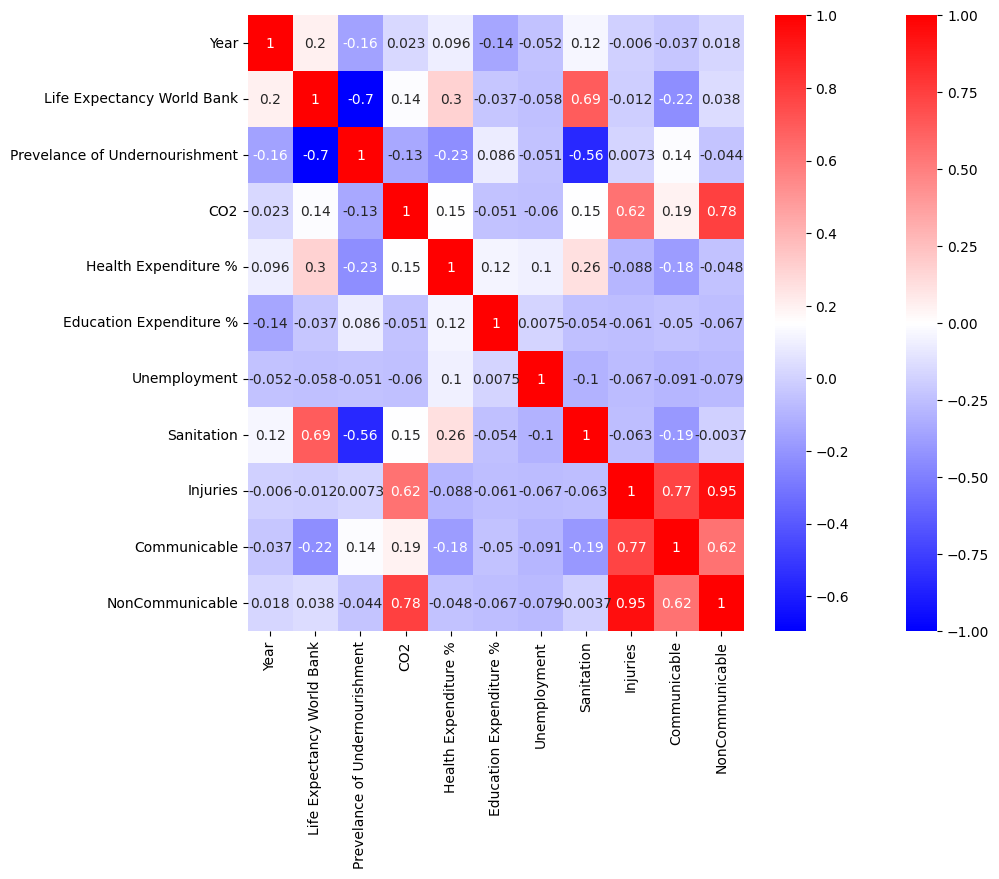

In [44]:
corr = data_drop_copy.select_dtypes(exclude=object).corr()
print(display(corr))

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    cmap='bwr'
)
#plt.xticks(rotation=90, ha='right', rotation_mode='anchor', annot=True, annot_kws={"size": 6});
sns.heatmap(corr, annot=True, cmap='bwr')
plt.show()

In [45]:
income_class_global = data_drop_copy.iloc[:, [2,5]]
income_class_global.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Region                      3306 non-null   object 
 1   Life Expectancy World Bank  3306 non-null   float64
dtypes: float64(1), object(1)
memory usage: 51.8+ KB


In [59]:
catg_heat_map_function = income_class_global[income_class_global['Region'] == 'South Asia'][['Life Expectancy World Bank']]
catg_heat_map_function

,Life Expectancy World Bank
0,56.308
16,65.956
26,61.808
72,62.907
89,72.233
...,...
3204,69.656
3221,76.978
3230,78.921
3251,70.778


In [55]:
catg_heat_map_function.shape

(152, 1)

In [63]:
# Calculate the mean Life Expectancy World Bank for each Region
regional_life_expectancy = income_class_global.groupby('Region')['Life Expectancy World Bank'].mean().reset_index()

# Set 'Region' as the index for plotting
regional_life_expectancy = regional_life_expectancy.set_index('Region')

regional_life_expectancy

,Life Expectancy World Bank
Region,
East Asia & Pacific,72.052260
Europe & Central Asia,76.182598
Latin America & Caribbean,73.591889
Middle East & North Africa,74.605994
North America,79.686498
South Asia,68.527579
Sub-Saharan Africa,57.542669


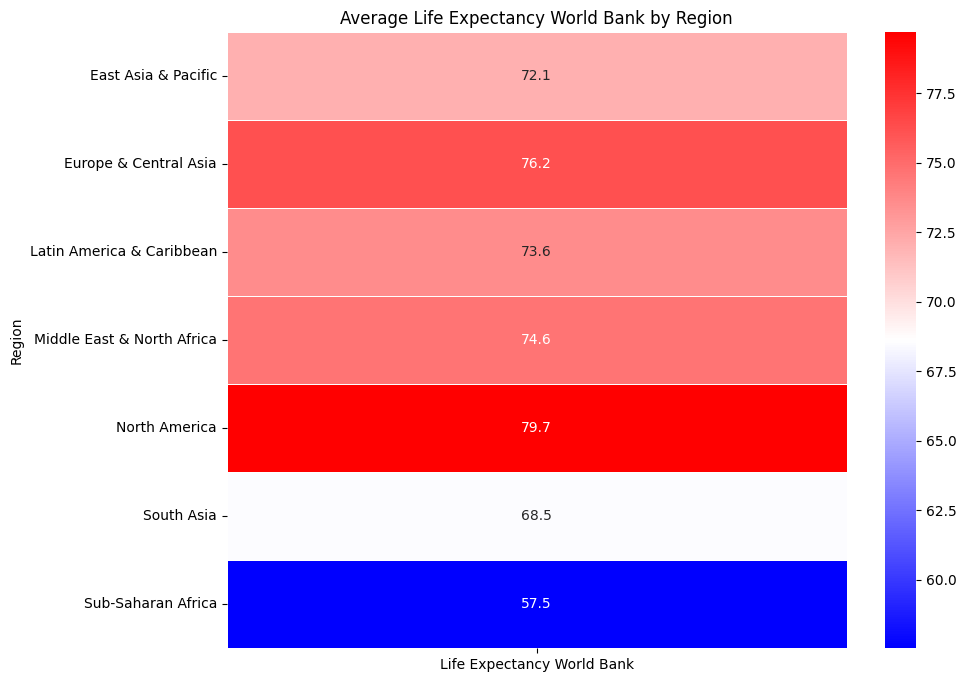

In [66]:
plt.figure(figsize=(10, 8)) # Adjust figure size as needed
sns.heatmap(regional_life_expectancy, annot=True, cmap='bwr', fmt=".1f", linewidths=.5)
plt.title('Average Life Expectancy World Bank by Region')
plt.xlabel('') # No x-label needed for single column
plt.ylabel('Region')
plt.yticks(rotation=0) # Ensure y-labels are readable
plt.show()

In [72]:
year_class_global = data_drop_copy.iloc[:, [4,5]]
year_class_global.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        3306 non-null   int64  
 1   Life Expectancy World Bank  3306 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 51.8 KB


In [74]:
year_heat_map_function = year_class_global[year_class_global['Year'] == 2017][['Life Expectancy World Bank']]
year_heat_map_function.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174 entries, 2784 to 2957
Data columns (total 1 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Life Expectancy World Bank  174 non-null    float64
dtypes: float64(1)
memory usage: 2.7 KB


In [86]:
# Calculate the mean Life Expectancy World Bank for each Year
year_life_expectancy = year_class_global.groupby('Year')['Life Expectancy World Bank'].mean()

# The result is already a Series with Year as the index

year_life_expectancy

,Life Expectancy World Bank
Year,
2001,66.926236
2002,67.194036
2003,67.453549
2004,67.828056
2005,68.120931
2006,68.489092
2007,68.854258
2008,69.254724
2009,69.662587


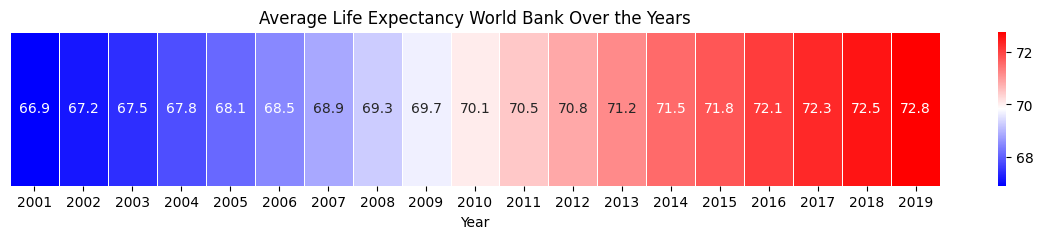

In [87]:
plt.figure(figsize=(15, 2)) # Adjust figure size for a horizontal heatmap
sns.heatmap(year_life_expectancy.to_frame().T, annot=True, cmap='bwr', fmt=".1f", linewidths=.5)
plt.title('Average Life Expectancy World Bank Over the Years')
plt.xlabel('Year') # Label for years as columns
plt.ylabel('') # Hide y-label as there's only one row (Life Expectancy)
plt.yticks([]) # Ensure y-labels are hidden
plt.show()

In [90]:
# Define the year you want to visualize
selected_year = 2016 # You can change this to any year between 2001 and 2019

# Filter the data for the selected year
data_for_selected_year = data_drop_copy[data_drop_copy['Year'] == selected_year]

# Calculate the mean Life Expectancy World Bank for each Region in the selected year
yearly_regional_life_expectancy = data_for_selected_year.groupby('Region')['Life Expectancy World Bank'].mean().reset_index()

# Set 'Region' as the index for plotting
yearly_regional_life_expectancy = yearly_regional_life_expectancy.set_index('Region')

yearly_regional_life_expectancy

,Life Expectancy World Bank
Region,
East Asia & Pacific,73.547640
Europe & Central Asia,77.721583
Latin America & Caribbean,74.799428
Middle East & North Africa,75.943311
North America,80.555366
South Asia,70.792375
Sub-Saharan Africa,61.547878


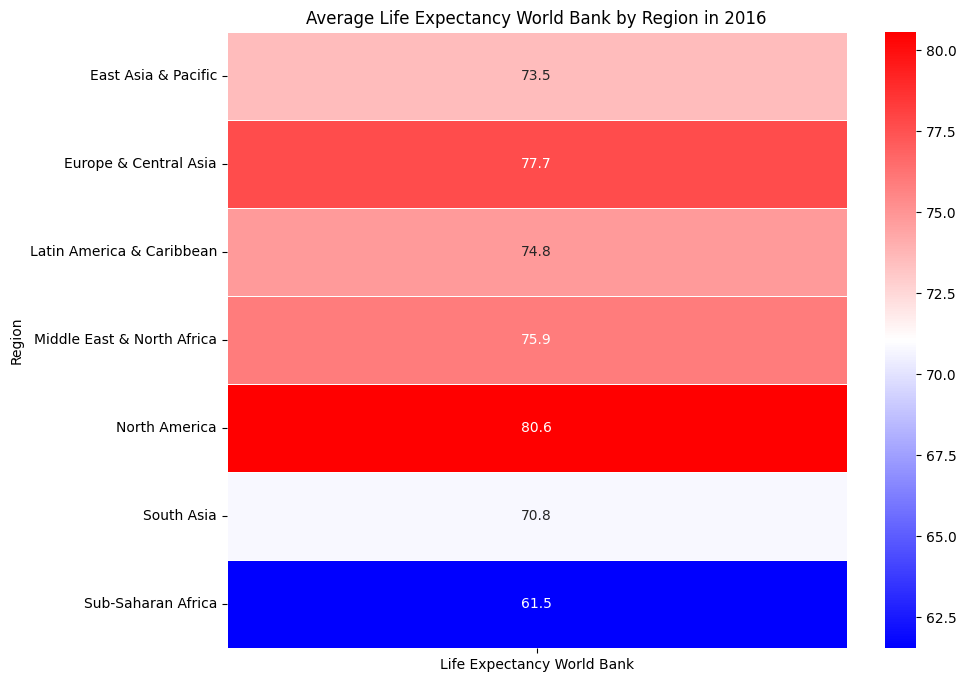

In [91]:
plt.figure(figsize=(10, 8)) # Adjust figure size as needed
sns.heatmap(yearly_regional_life_expectancy, annot=True, cmap='bwr', fmt=".1f", linewidths=.5)
plt.title(f'Average Life Expectancy World Bank by Region in {selected_year}')
plt.xlabel('') # No x-label needed for single column
plt.ylabel('Region')
plt.yticks(rotation=0) # Ensure y-labels are readable
plt.show()

,Life Expectancy World Bank
Year,
2001,66.926236
2002,67.194036
2003,67.453549
2004,67.828056
2005,68.120931
2006,68.489092
2007,68.854258
2008,69.254724
2009,69.662587
